In [1]:
import gdown
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
file_id = "1eHwjSb73Ut737L8rR3fEVkkhSjKWItL1"
download_url = f"https://drive.google.com/uc?id={file_id}"

In [3]:
output_file = "linkedin_dataset.csv"

In [4]:
gdown.download(download_url, output_file, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1eHwjSb73Ut737L8rR3fEVkkhSjKWItL1
From (redirected): https://drive.google.com/uc?id=1eHwjSb73Ut737L8rR3fEVkkhSjKWItL1&confirm=t&uuid=18b248b9-b617-4082-832b-2818cdb07954
To: /content/linkedin_dataset.csv
100%|██████████| 517M/517M [00:09<00:00, 54.5MB/s]


'linkedin_dataset.csv'

In [5]:
data = pd.read_csv(output_file)

In [6]:
data

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123844,3906267117,Lozano Smith,Title IX/Investigations Attorney,Our Walnut Creek office is currently seeking a...,195000.0,YEARLY,"Walnut Creek, CA",56120.0,1.0,NaN,...,NaN,1.713571e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,94595.0,6013.0
123845,3906267126,Pinterest,"Staff Software Engineer, ML Serving Platform",About Pinterest:\n\nMillions of people across ...,NaN,NaN,United States,1124131.0,3.0,NaN,...,NaN,1.713572e+12,www.pinterestcareers.com,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN
123846,3906267131,EPS Learning,"Account Executive, Oregon/Washington",Company Overview\n\nEPS Learning is a leading ...,NaN,NaN,"Spokane, WA",90552133.0,3.0,NaN,...,NaN,1.713572e+12,epsoperations.bamboohr.com,0,FULL_TIME,NaN,NaN,NaN,99201.0,53063.0
123847,3906267195,Trelleborg Applied Technologies,Business Development Manager,The Business Development Manager is a 'hunter'...,NaN,NaN,"Texas, United States",2793699.0,4.0,NaN,...,NaN,1.713573e+12,NaN,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN


# Data Cleaning

## Inspecting Missing Data


Data quality issues are common in large job-posting datasets. On a platform like LinkedIn, missing or inconsistent information can arise from incomplete job submissions, variations in employer input formats, or differences in how external application partners provide data. As data analysts, we assess the extent of missing or inconsistent fields, evaluate their impact on Hiring Efficiency analysis, and apply appropriate cleaning steps. This includes standardizing column formats, fixing data types, parsing locations, deriving consistent categorical fields, handling outliers, and creating reliable metrics that allow us to compare roles, salary ranges, and locations accurately.

In [7]:
#missing columns
missing_value_columns = data.isnull().sum()

In [8]:
print("Missing Value Columns:\n", missing_value_columns,)

Missing Value Columns:
 job_id                             0
company_name                    1719
title                              0
description                        7
max_salary                     94056
pay_period                     87776
location                           0
company_id                      1717
views                           1689
med_salary                    117569
min_salary                     94056
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                108603
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain                 39968
sponsored                          0
work_type                          0
currency      

In [9]:
missing_count = data.isnull().sum()
missing_percentage = (missing_count / len(data)) * 100

In [10]:
print("Missing value percentage:\n", missing_percentage)

Missing value percentage:
 job_id                         0.000000
company_name                   1.387981
title                          0.000000
description                    0.005652
max_salary                    75.944093
pay_period                    70.873402
location                       0.000000
company_id                     1.386366
views                          1.363757
med_salary                    94.929309
min_salary                    75.944093
formatted_work_type            0.000000
applies                       81.170619
original_listed_time           0.000000
remote_allowed                87.689848
job_posting_url                0.000000
application_url               29.604599
application_type               0.000000
expiry                         0.000000
closed_time                   99.133622
formatted_experience_level    23.745852
skills_desc                   98.030666
listed_time                    0.000000
posting_domain                32.271556
sponsored    

In [11]:
#checking numeric missing values
num_cols = [
    "applies", "views",
    "max_salary", "min_salary", "med_salary", "normalized_salary",
    "company_id", "zip_code", "fips",
    "remote_allowed", "sponsored"
]

for col in num_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

In [12]:
# Compute median applies per company and imputing the medians
company_medians = (
    data.dropna(subset=['company_name'])
        .groupby('company_name')['applies']
        .median()
)

def fill_apply(row):
    comp = row['company_name']

    if pd.isna(row['applies']):
        #missing values
        if pd.isna(comp):
            return global_median


        if comp not in company_medians:
            return global_median


        return company_medians[comp]


    return row['applies']

global_median = data['applies'].median()

#No of applies
data['applies'] = data.apply(fill_apply, axis=1)

data['applies'].describe()

,applies
count,88338.000000
mean,5.135944
std,16.992009
min,1.000000
25%,1.000000
50%,2.000000
75%,3.500000
max,967.000000


In [13]:
data['company_name'] = data['company_name'].fillna("Unknown Company")
data['title'] = data['title'].fillna("Not Specified")
data['location'] = data['location'].fillna("Unknown Location")
data['formatted_work_type'] = data['formatted_work_type'].fillna("Unknown")
data['formatted_experience_level'] = data['formatted_experience_level'].fillna("Not Mentioned")
data['posting_domain'] = data['posting_domain'].fillna("linkedin.com")
data['description'] = data['description'].fillna("No Description Provided")
data['skills_desc'] = data['skills_desc'].fillna("Not Listed")

#Salary-medians
for col in ['min_salary', 'max_salary', 'med_salary', 'normalized_salary', 'views']:
    if col in data.columns:
        data[col] = data[col].fillna(data[col].median())

# Binary-fill 0
for col in ['remote_allowed', 'sponsored']:
    if col in data.columns:
        data[col] = data[col].fillna(0)

# ZIP-replace with 0
for col in ['zip_code', 'fips']:
    if col in data.columns:
        data[col] = data[col].fillna(0)

In [14]:
#dropping unncessary columns
cols_to_drop = [

    'application_url',
    'sponsored'
    'closed_time',
]

cols_to_drop = [col for col in cols_to_drop if col in data.columns]

data.drop(columns=cols_to_drop, inplace=True)

data

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,25.5,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,linkedin.com,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,Unknown Company,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,25.5,...,Not Listed,1.712858e+12,linkedin.com,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,25.5,...,We are currently accepting resumes for FOH - A...,1.713278e+12,linkedin.com,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,25.5,...,This position requires a baseline understandin...,1.712896e+12,linkedin.com,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,Unknown Company,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,25.5,...,Not Listed,1.713452e+12,linkedin.com,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123844,3906267117,Lozano Smith,Title IX/Investigations Attorney,Our Walnut Creek office is currently seeking a...,195000.0,YEARLY,"Walnut Creek, CA",56120.0,1.0,25.5,...,Not Listed,1.713571e+12,linkedin.com,0,FULL_TIME,USD,BASE_SALARY,157500.0,94595.0,6013.0
123845,3906267126,Pinterest,"Staff Software Engineer, ML Serving Platform",About Pinterest:\n\nMillions of people across ...,80000.0,NaN,United States,1124131.0,3.0,25.5,...,Not Listed,1.713572e+12,www.pinterestcareers.com,0,FULL_TIME,NaN,NaN,81500.0,0.0,0.0
123846,3906267131,EPS Learning,"Account Executive, Oregon/Washington",Company Overview\n\nEPS Learning is a leading ...,80000.0,NaN,"Spokane, WA",90552133.0,3.0,25.5,...,Not Listed,1.713572e+12,epsoperations.bamboohr.com,0,FULL_TIME,NaN,NaN,81500.0,99201.0,53063.0
123847,3906267195,Trelleborg Applied Technologies,Business Development Manager,The Business Development Manager is a 'hunter'...,80000.0,NaN,"Texas, United States",2793699.0,4.0,25.5,...,Not Listed,1.713573e+12,linkedin.com,0,FULL_TIME,NaN,NaN,81500.0,0.0,0.0


## Handling Outliers
Before proceeding we check for the values that outtside the normal range of distributions so that they do not overpower rest of the data set and avoid any problems due to momentary spikes.
We use IQR for outliers

In [15]:
#Detecting outliers
for col in ['applies', 'views']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower, upper)

# Normalisation
Before comparing different metrics we Normalise the important numeric columns like salary and applies which have very wide range and bring them into comaparable scales.

In [16]:

# Normalising Numeric Columns

norm_cols = ['applies', 'views']

for col in norm_cols:
    if col in data.columns:
        col_min = data[col].min()
        col_max = data[col].max()
        data[col + "_scaled"] = (data[col] - col_min) / (col_max - col_min + 1e-9)


In [17]:
data['applies'].describe()

,applies
count,88338.000000
mean,2.673903
std,2.197092
min,1.000000
25%,1.000000
50%,2.000000
75%,3.500000
max,7.250000


# Hiring Efficiency:
Our main objective is to analyse and improve Hiring efficiency. Hiring efficiency shows how many users took interest and applied in the post.By looking at efficiency from multiple angles, we get a clearer picture of how the job market is behaving and what is actually driving engagement on LinkedIn.This helps us see which kinds of roles naturally attract more applicants and where companies might need to adjust their strategy.

In [18]:
#Overall Hiring efficiency
total_postings = len(data)
total_applicants = data['applies'].sum()
overall_hiring_efficiency = total_applicants / total_postings

print("Postings:", total_postings)
print("Total Applicants:", total_applicants)
print("Net Hiring Efficiency:", overall_hiring_efficiency)

Postings: 123849
Total Applicants: 236207.25
Net Hiring Efficiency: 1.9072196788024127


## Hiring efficiency accross different factors
We analyse the possible hiring efficiency accross different types of categories before taking any hypothesis into consideration

In [19]:
#Hiring efficiency for companies
he_company = (
    data.groupby('company_name')
        .agg(
            total_postings=('job_id', 'count'),
            total_applicants=('applies', 'sum')
        )
        .assign(hiring_efficiency=lambda x: x['total_applicants'] / x['total_postings'])
        .sort_values('hiring_efficiency', ascending=False)
        .reset_index()
)

he_company

,company_name,total_postings,total_applicants,hiring_efficiency
0,"IdeaHelix, Inc",1,7.25,7.25
1,1A1 Innovations,1,7.25,7.25
2,"Idea Nuova, Inc.",1,7.25,7.25
3,Giant Noise,2,14.50,7.25
4,CRM Technical Staffing,3,21.75,7.25
...,...,...,...,...
24424,1080 Learning Center,1,0.00,0.00
24425,101 Studios,1,0.00,0.00
24426,"10-D, Inc. Academy ● Compliance ● Info Security",1,0.00,0.00
24427,10 Fitness,9,0.00,0.00


In [20]:
#Hiring efficiency by job title
he_title = (
    data.groupby('title')
        .agg(
            total_postings=('job_id', 'count'),
            total_applicants=('applies', 'sum'),
            median_salary=('normalized_salary', 'median')
        )
        .assign(hiring_efficiency=lambda x: x['total_applicants'] / x['total_postings'])
        .sort_values('hiring_efficiency', ascending=False)
        .reset_index()
)

he_title

,title,total_postings,total_applicants,median_salary,hiring_efficiency
0,Senior ETL Data Engineer (100% Remote),1,7.25,81500.0,7.25
1,.NET Full Stack Developer/Technical Lead,1,7.25,81500.0,7.25
2,Accounting Manager,1,7.25,81500.0,7.25
3,Chief of Staff – Executive Business Manager,1,7.25,81500.0,7.25
4,Azure Data Architect,1,7.25,166400.0,7.25
...,...,...,...,...,...
72516,MS Travel LPN - Job Id: JO03715786,1,0.00,81500.0,0.00
72517,MS Travel LPN - Job Id: JO03716427,1,0.00,81500.0,0.00
72518,MS Travel LPN - Job Id: JO03721345,1,0.00,81500.0,0.00
72519,MS Travel LPN - Job Id: JO03721363,1,0.00,81500.0,0.00


In [21]:
he_location = (
    data.groupby('location')
        .agg(
            total_postings=('job_id', 'count'),
            total_applicants=('applies', 'sum'),
            median_salary=('normalized_salary', 'median')
        )
        .assign(hiring_efficiency=lambda x: x['total_applicants'] / x['total_postings'])
        .sort_values('hiring_efficiency', ascending=False)
        .reset_index()
)

he_location.sort_values('hiring_efficiency', ascending=False)

,location,total_postings,total_applicants,median_salary,hiring_efficiency
39,"Brodheadsville, PA",1,7.25,81500.0,7.25
31,"Cañon City, CO",1,7.25,81500.0,7.25
0,"Jefferson Valley-Yorktown, NY",1,7.25,39520.0,7.25
1,"North Syracuse, NY",1,7.25,105000.0,7.25
2,"Capital, IL",1,7.25,81500.0,7.25
...,...,...,...,...,...
7384,"Yolo County, CA",1,0.00,57336.0,0.00
7383,"Abbeville, SC",1,0.00,81500.0,0.00
7382,"Austintown, OH",2,0.00,81500.0,0.00
7381,"New Cumberland, PA",2,0.00,81500.0,0.00


In [22]:
he_seniority = (
    data.groupby('formatted_experience_level')
        .agg(
            total_postings=('job_id', 'count'),
            total_applicants=('applies', 'sum'),
            median_salary=('normalized_salary', 'median')
        )
        .assign(hiring_efficiency=lambda x: x['total_applicants'] / x['total_postings'])
        .sort_values('hiring_efficiency', ascending=False)
        .reset_index()
)

he_seniority

,formatted_experience_level,total_postings,total_applicants,median_salary,hiring_efficiency
0,Associate,9826,24493.50,81500.0,2.492723
1,Executive,1222,3009.75,81500.0,2.462971
2,Director,3746,8520.75,81500.0,2.274626
3,Mid-Senior level,41489,88548.75,81500.0,2.134271
4,Not Mentioned,29409,55546.75,81500.0,1.888767
5,Internship,1449,2728.50,81500.0,1.883023
6,Entry level,36708,53359.25,81500.0,1.453614


In [23]:
he_work_type = (
    data.groupby('formatted_work_type')
        .agg(
            total_postings=('job_id', 'count'),
            total_applicants=('applies', 'sum'),
            median_salary=('normalized_salary', 'median')
        )
        .assign(hiring_efficiency=lambda x: x['total_applicants'] / x['total_postings'])
        .sort_values('hiring_efficiency', ascending=False)
        .reset_index()
)

he_work_type

,formatted_work_type,total_postings,total_applicants,median_salary,hiring_efficiency
0,Contract,12117,43530.00,81500.0,3.592473
1,Internship,983,2176.25,81500.0,2.213886
2,Full-time,98814,173762.75,81500.0,1.758483
3,Temporary,1190,1899.50,81500.0,1.596218
4,Other,487,712.25,81500.0,1.462526
5,Part-time,9696,13656.75,81500.0,1.408493
6,Volunteer,562,469.75,81500.0,0.835854


**Contractual and internships are seen to have more applies possibly the users looking for starting their career. Full time also have nice efficiency despite being large number.**

In [24]:
he_remote = (
    data.groupby('remote_allowed')
        .agg(
            total_postings=('job_id', 'count'),
            total_applicants=('applies', 'sum'),
            median_salary=('normalized_salary', 'median')
        )
        .assign(hiring_efficiency=lambda x: x['total_applicants'] / x['total_postings'])
        .sort_values('hiring_efficiency', ascending=False)
        .reset_index()
)

he_remote

,remote_allowed,total_postings,total_applicants,median_salary,hiring_efficiency
0,1.0,15246,49420.25,81500.0,3.241522
1,0.0,108603,186787.00,81500.0,1.719906


**Availability of remote increases the Hiring efficiency.**

In [25]:
if 'posting_count' not in data.columns:
    data['posting_count'] = 1

step = 50000

sal_min = max(0, data['normalized_salary'].min())
sal_max = data['normalized_salary'].max()

bins = list(np.arange(0, sal_max + step, step))
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins) - 1)]

data['salary_band'] = pd.cut(
    data['normalized_salary'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

he_by_salary = (
    data.dropna(subset=['salary_band'])
        .groupby('salary_band', observed=True)
        .agg(
            total_postings=('posting_count', 'sum'),
            total_applicants=('applies', 'sum')
        )
        .reset_index()
)

he_by_salary['hiring_efficiency'] = (
    he_by_salary['total_applicants'] / he_by_salary['total_postings']
)
he_by_salary

,salary_band,total_postings,total_applicants,hiring_efficiency
0,0-50000,8403,13494.75,1.605944
1,50000-100000,101449,184947.00,1.823054
2,100000-150000,8521,22547.00,2.646051
3,150000-200000,3596,10363.75,2.882022
4,200000-250000,1109,3027.00,2.729486
5,250000-300000,373,841.75,2.256702
6,300000-350000,148,389.25,2.630068
7,350000-400000,71,178.50,2.514085
8,400000-450000,44,106.50,2.420455
9,450000-500000,32,62.75,1.960938


# **Testing Hypothesis**



## Part 1: Job Attractiveness

**Hypothesis 1:** Job clusters show significant differences in hiring efficiency, with high-skill technical and leadership roles expected to outperform service-oriented clusters.




In [26]:
#To make analysis simple we cluster the Job Titles to clusters using k-means clustering

def classify_title(title):
    title = str(title).lower()

    if any(k in title for k in [
        'engineer','developer','software','it','cloud','data','machine learning',
        'devops','analyst','programmer'
    ]):
        return 'Software & IT'

    if any(k in title for k in [
        'nurse','therapist','counselor','clinician','medical','health','physician',
        'doctor','dental','rn','lpn'
    ]):
        return 'Healthcare & Medical'

    if any(k in title for k in [
        'sales','marketing','account manager','business development','customer'
    ]):
        return 'Sales, Marketing & Customer Success'

    if any(k in title for k in [
        'finance','financial','accountant','tax','audit','billing','insurance'
    ]):
        return 'Finance, Accounting & Insurance'

    if any(k in title for k in [
        'hr','human resources','recruiter','coordinator','assistant','office',
        'operations','admin'
    ]):
        return 'Admin, HR & Operations'

    if any(k in title for k in [
        'attorney','associate','law','legal','paralegal','compliance'
    ]):
        return 'Legal & Compliance'

    if any(k in title for k in [
        'technician','mechanic','construction','hvac','electrician',
        'operator','warehouse','skilled'
    ]):
        return 'Manufacturing & Skilled Trades'

    if any(k in title for k in [
        'restaurant','chef','cook','server','cashier','barista','retail','hospitality'
    ]):
        return 'Food Service, Retail & Hospitality'

    if any(k in title for k in [
        'teacher','instructor','professor','trainer','coach'
    ]):
        return 'Education & Training'

    if any(k in title for k in [
        'director','vice president','vp','chief','manager'
    ]):
        return 'Executive & Leadership'

    return 'Other'


data['job_cluster'] = data['title'].apply(classify_title)
data

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,currency,compensation_type,normalized_salary,zip_code,fips,applies_scaled,views_scaled,posting_count,salary_band,job_cluster
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,13.0,25.5,...,USD,BASE_SALARY,38480.0,8540.0,34021.0,0.16,1.000000,1,0-50000,"Sales, Marketing & Customer Success"
1,1829192,Unknown Company,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,25.5,...,USD,BASE_SALARY,83200.0,80521.0,8069.0,0.32,0.000000,1,50000-100000,Healthcare & Medical
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,25.5,...,USD,BASE_SALARY,55000.0,45202.0,39061.0,NaN,0.583333,1,50000-100000,Software & IT
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,13.0,25.5,...,USD,BASE_SALARY,157500.0,11040.0,36059.0,NaN,1.000000,1,150000-200000,Healthcare & Medical
4,35982263,Unknown Company,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,25.5,...,USD,BASE_SALARY,70000.0,52601.0,19057.0,0.32,0.166667,1,50000-100000,Manufacturing & Skilled Trades
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123844,3906267117,Lozano Smith,Title IX/Investigations Attorney,Our Walnut Creek office is currently seeking a...,195000.0,YEARLY,"Walnut Creek, CA",56120.0,1.0,25.5,...,USD,BASE_SALARY,157500.0,94595.0,6013.0,NaN,0.000000,1,150000-200000,Software & IT
123845,3906267126,Pinterest,"Staff Software Engineer, ML Serving Platform",About Pinterest:\n\nMillions of people across ...,80000.0,NaN,United States,1124131.0,3.0,25.5,...,NaN,NaN,81500.0,0.0,0.0,1.00,0.166667,1,50000-100000,Software & IT
123846,3906267131,EPS Learning,"Account Executive, Oregon/Washington",Company Overview\n\nEPS Learning is a leading ...,80000.0,NaN,"Spokane, WA",90552133.0,3.0,25.5,...,NaN,NaN,81500.0,99201.0,53063.0,NaN,0.166667,1,50000-100000,Other
123847,3906267195,Trelleborg Applied Technologies,Business Development Manager,The Business Development Manager is a 'hunter'...,80000.0,NaN,"Texas, United States",2793699.0,4.0,25.5,...,NaN,NaN,81500.0,0.0,0.0,NaN,0.250000,1,50000-100000,"Sales, Marketing & Customer Success"


In [27]:
he_job_cluster = (
    data.groupby('job_cluster')
        .agg(
            total_postings=('job_id', 'count'),
            total_applicants=('applies', 'sum'),
            median_salary=('normalized_salary', 'median')
        )
        .assign(hiring_efficiency=lambda x: x['total_applicants'] / x['total_postings'])
        .sort_values('hiring_efficiency', ascending=False)
        .reset_index()
)

he_job_cluster

,job_cluster,total_postings,total_applicants,median_salary,hiring_efficiency
0,Software & IT,34790,87709.50,81500.0,2.521112
1,Executive & Leadership,9525,19862.25,81500.0,2.085276
2,"Finance, Accounting & Insurance",3345,6692.50,81500.0,2.000747
3,"Sales, Marketing & Customer Success",12249,22615.75,81500.0,1.846334
4,"Admin, HR & Operations",10983,19654.50,81500.0,1.789538
5,Legal & Compliance,3544,6127.50,81500.0,1.728979
6,Other,25599,42737.50,81500.0,1.669499
7,Manufacturing & Skilled Trades,7291,10532.50,81500.0,1.444589
8,"Food Service, Retail & Hospitality",1750,2190.50,81500.0,1.251714
9,Healthcare & Medical,13637,16766.00,81500.0,1.229449


/tmp/ipython-input-3720002732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


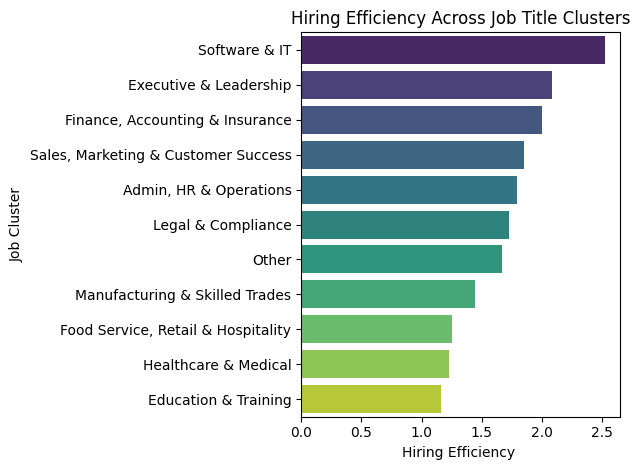

In [28]:

plt.figure()
sns.barplot(
    data=he_job_cluster,
    x='hiring_efficiency',
    y='job_cluster',
    palette='viridis'
)

plt.title("Hiring Efficiency Across Job Title Clusters")
plt.xlabel("Hiring Efficiency ")
plt.ylabel("Job Cluster")
plt.tight_layout()
plt.show()

So our hypothesis is correct. Job clusters differ significantly, and high-skill tech/leadership domains show the highest hiring efficiency relative to service and education roles.


**Hypothesis 2:** Entry-level roles receive higher hiring efficiency than mid-level or senior roles.

In [29]:
he_experience = (
    data.groupby('formatted_experience_level')
        .agg(
            total_postings=('job_id', 'count'),
            total_applicants=('applies', 'sum'),
            median_salary=('normalized_salary', 'median')
        )
        .assign(hiring_efficiency=lambda x: x['total_applicants'] / x['total_postings'])
        .sort_values('hiring_efficiency', ascending=False)
        .reset_index()
)

he_experience

,formatted_experience_level,total_postings,total_applicants,median_salary,hiring_efficiency
0,Associate,9826,24493.50,81500.0,2.492723
1,Executive,1222,3009.75,81500.0,2.462971
2,Director,3746,8520.75,81500.0,2.274626
3,Mid-Senior level,41489,88548.75,81500.0,2.134271
4,Not Mentioned,29409,55546.75,81500.0,1.888767
5,Internship,1449,2728.50,81500.0,1.883023
6,Entry level,36708,53359.25,81500.0,1.453614


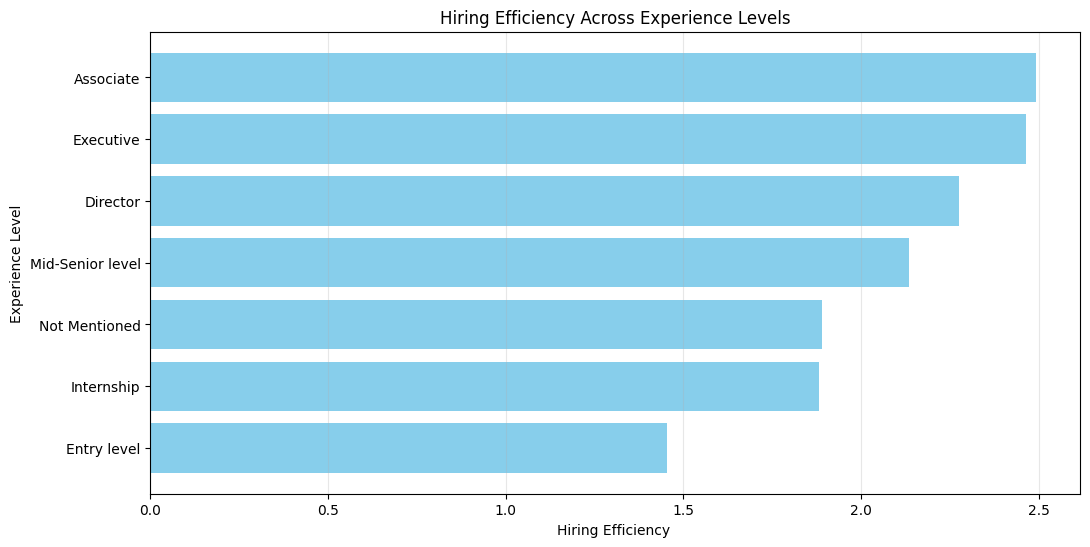

In [30]:
plt.figure(figsize=(12,6))
plt.barh(
    he_experience['formatted_experience_level'],
    he_experience['hiring_efficiency'],
    color='skyblue'
)
plt.xlabel("Hiring Efficiency ")
plt.ylabel("Experience Level")
plt.title("Hiring Efficiency Across Experience Levels")
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.show()

**Hypothesis 3:** Full-time jobs show higher hiring efficiency compared to contract or internship roles.

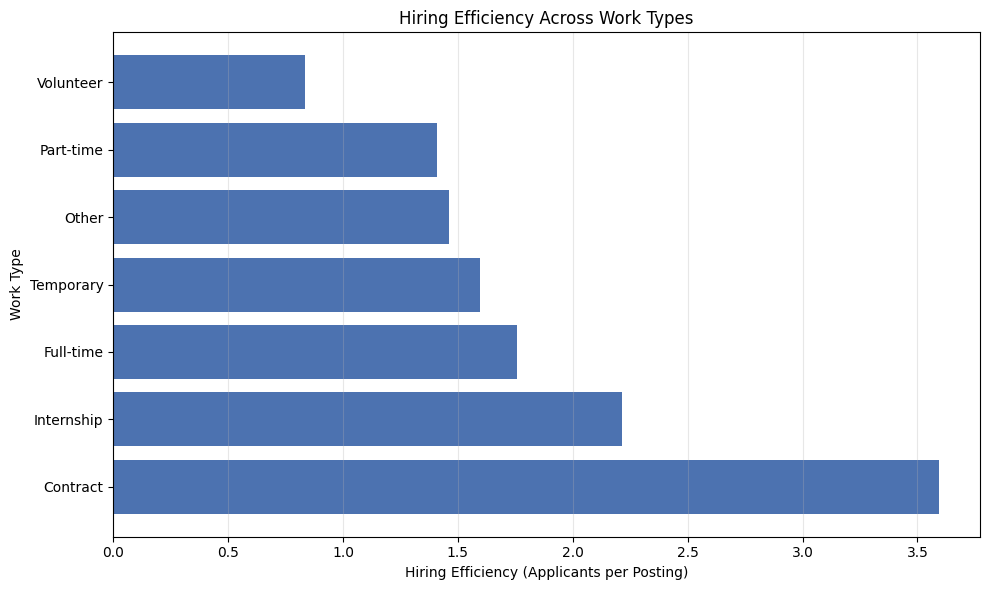

In [31]:
plt.figure(figsize=(10,6))
plt.barh(
    he_work_type['formatted_work_type'],
    he_work_type['hiring_efficiency'],
    color="#4C72B0"
)

plt.xlabel("Hiring Efficiency (Applicants per Posting)")
plt.ylabel("Work Type")
plt.title("Hiring Efficiency Across Work Types")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Hypothesis 4:** Internship roles attract many applicants but may show lower efficiency due to high postings volume.

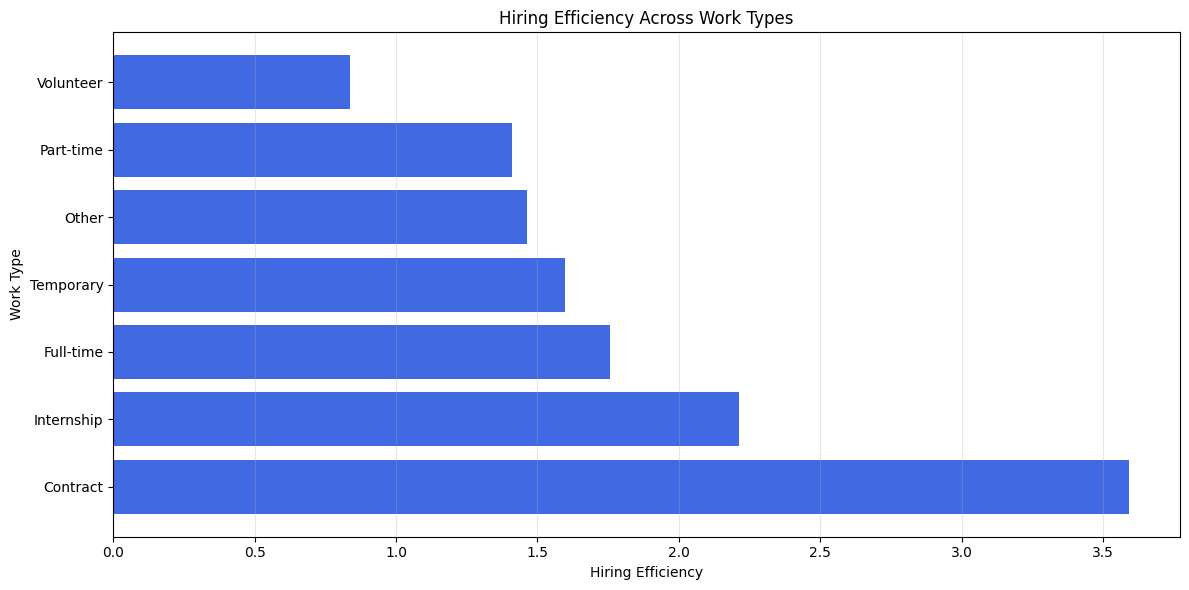

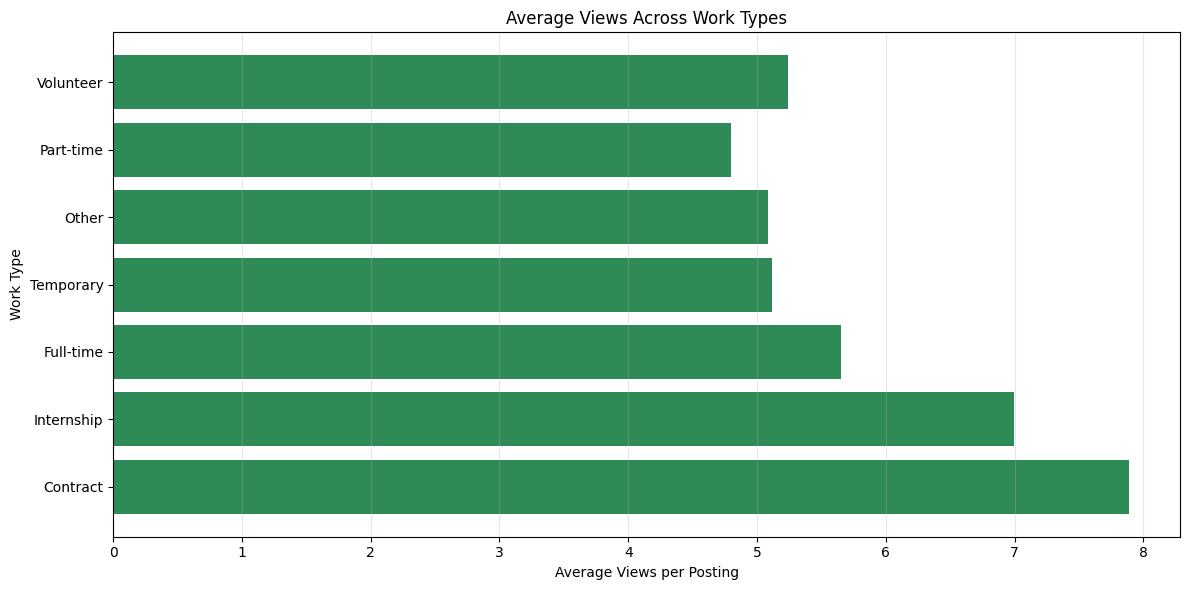

In [32]:
he_work_type = (
    data.groupby('formatted_work_type')
        .agg(
            total_postings=('job_id', 'count'),
            total_applicants=('applies', 'sum'),
            total_views=('views', 'sum')
        )
        .assign(
            hiring_efficiency=lambda x: x['total_applicants'] / x['total_postings'],
            avg_views_per_post=lambda x: x['total_views'] / x['total_postings']
        )
        .sort_values('hiring_efficiency', ascending=False)
        .reset_index()
)

# Hiring Efficiency
plt.figure(figsize=(12,6))
plt.barh(he_work_type['formatted_work_type'], he_work_type['hiring_efficiency'], color='royalblue')
plt.xlabel("Hiring Efficiency")
plt.ylabel("Work Type")
plt.title("Hiring Efficiency Across Work Types")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Views per Posting
plt.figure(figsize=(12,6))
plt.barh(he_work_type['formatted_work_type'], he_work_type['avg_views_per_post'], color='seagreen')
plt.xlabel("Average Views per Posting")
plt.ylabel("Work Type")
plt.title("Average Views Across Work Types")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Hypothesis 5:** Roles requiring extensive experience (5+ years) show lower hiring efficiency.


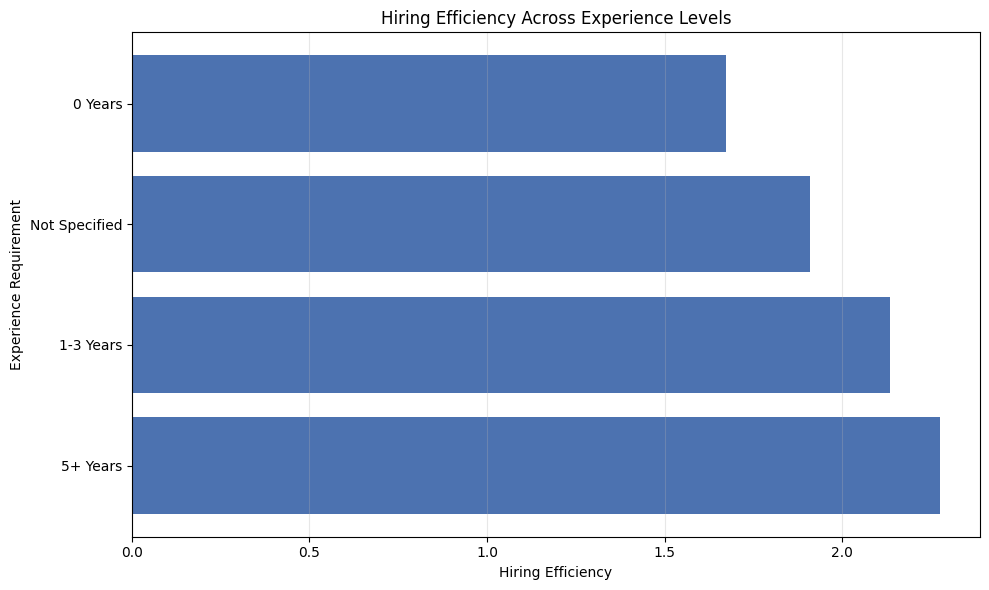

In [33]:
data1 = data.copy()

def extract_experience(level):
    level = str(level).lower()

    if "entry" in level or "associate" in level:
        return 0
    if "senior" in level and "mid" not in level:
        return 5
    if "mid" in level:
        return 3
    if "director" in level or "leadership" in level or "vp" in level:
        return 8
    return np.nan

data1["exp_years"] = data1["formatted_experience_level"].apply(extract_experience)


def bucket_exp(x):
    if pd.isna(x):
        return "Not Specified"
    if x == 0:
        return "0 Years"
    if x <= 3:
        return "1-3 Years"
    if x <= 5:
        return "3-5 Years"
    return "5+ Years"

data1["experience_bucket"] = data1["exp_years"].apply(bucket_exp)


he_experience = (
    data1.groupby("experience_bucket")
      .agg(
          total_postings=("job_id", "count"),
          total_applicants=("applies", "sum")
      )
      .assign(hiring_efficiency=lambda x: x["total_applicants"] / x["total_postings"])
      .sort_values("hiring_efficiency", ascending=False)
      .reset_index()
)



plt.figure(figsize=(10,6))
plt.barh(
    he_experience["experience_bucket"],
    he_experience["hiring_efficiency"],
    color="#4C72B0"
)
plt.xlabel("Hiring Efficiency")
plt.ylabel("Experience Requirement")
plt.title("Hiring Efficiency Across Experience Levels")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Part 2: Salary based

**Hypothesis 6:** Jobs offering salaries above the cluster median have higher hiring efficiency.

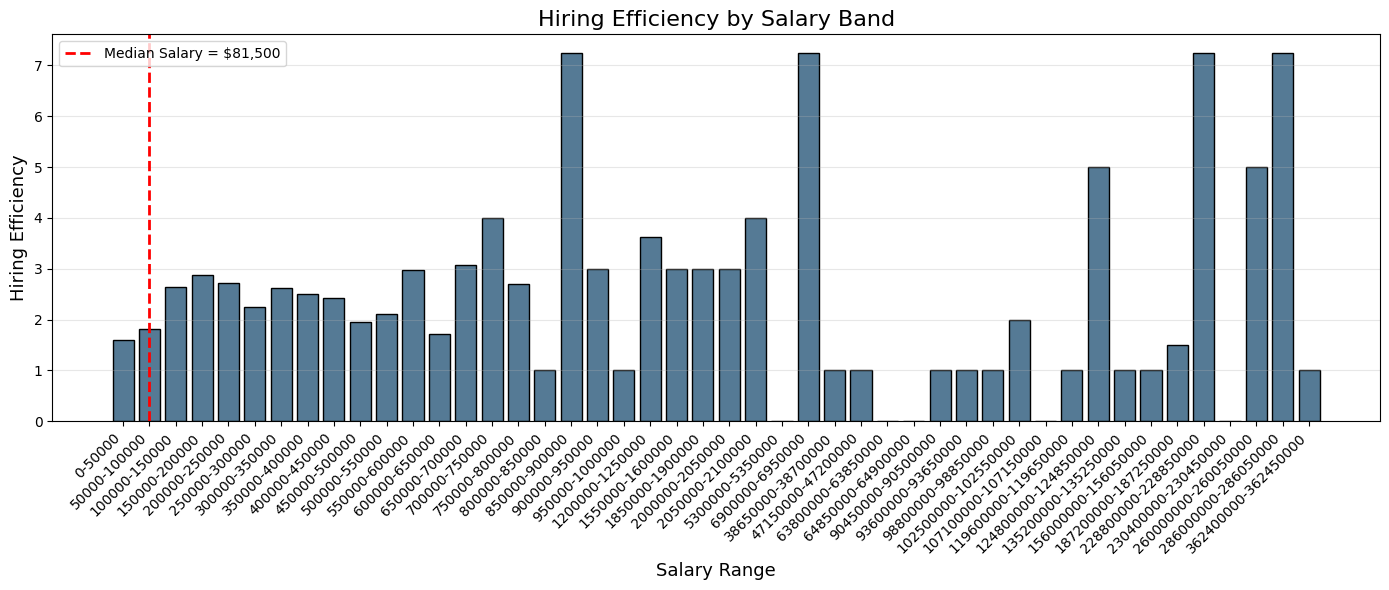

In [34]:
plt.figure(figsize=(14, 6))
plt.bar(
    he_by_salary['salary_band'],
    he_by_salary['hiring_efficiency'],
    color="#557A95",
    edgecolor="black"
)

#median
median_salary = data['normalized_salary'].median()

median_band_index = None
for i, b in enumerate(bins):
    if median_salary >= bins[i] and median_salary < bins[i+1]:
        median_band_index = i
        break

if median_band_index is not None:
    plt.axvline(
        median_band_index,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f"Median Salary = ${median_salary:,.0f}"
    )

plt.title("Hiring Efficiency by Salary Band", fontsize=16)
plt.xlabel("Salary Range", fontsize=13)
plt.ylabel("Hiring Efficiency", fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Hypothesis 7:** Yearly salary postings generate higher efficiency only for senior or high-skill positions.


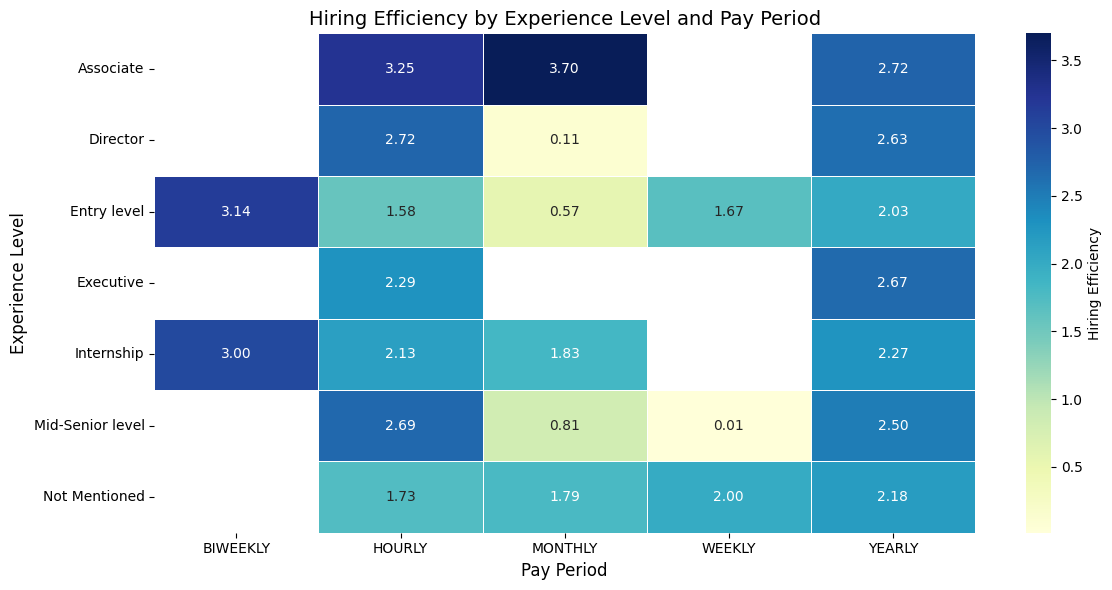

In [35]:
he_heatmap = (
    data.groupby(['formatted_experience_level', 'pay_period'])
        .agg(
            total_postings=('job_id', 'count'),
            total_applicants=('applies', 'sum')
        )
        .assign(hiring_efficiency=lambda x: x['total_applicants'] / x['total_postings'])
        .reset_index()
)


heatmap_matrix = he_heatmap.pivot(
    index='formatted_experience_level',
    columns='pay_period',
    values='hiring_efficiency'
)


plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': 'Hiring Efficiency'}
)

plt.title("Hiring Efficiency by Experience Level and Pay Period", fontsize=14)
plt.xlabel("Pay Period", fontsize=12)
plt.ylabel("Experience Level", fontsize=12)
plt.tight_layout()
plt.show()

**Hypothesis 8:** Hourly pay postings have more hiring efficiency compared to Yearly postings for service-sector roles.

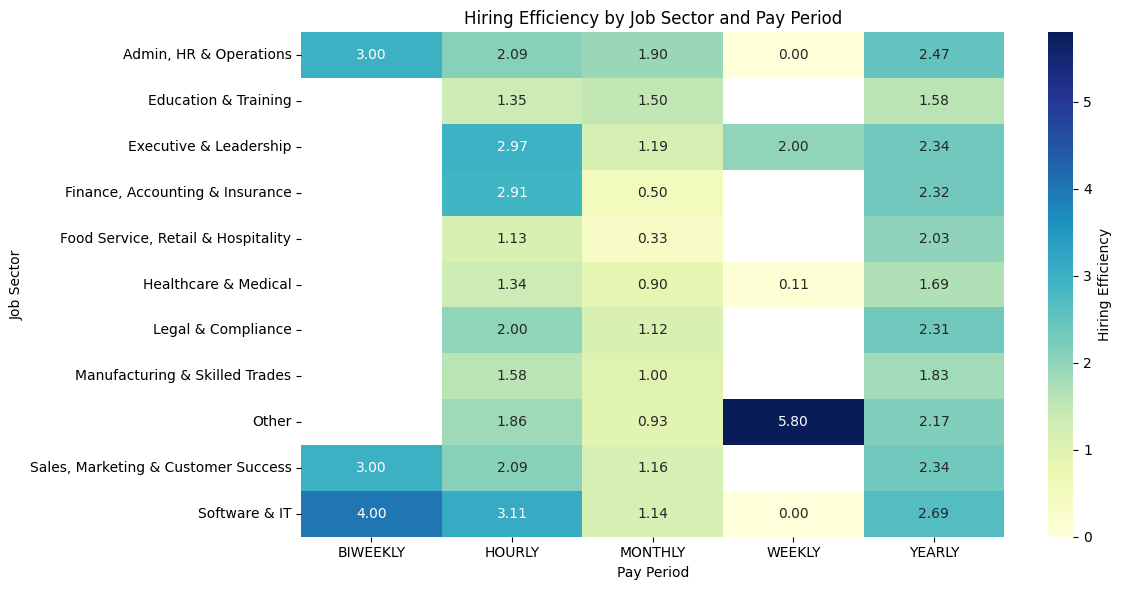

In [36]:
he_heatmap = (
    data.groupby(['job_cluster', 'pay_period'])
        .agg(
            total_postings=('job_id', 'count'),
            total_applicants=('applies', 'sum')
        )
        .assign(hiring_efficiency=lambda x: x['total_applicants'] / x['total_postings'])
        .reset_index()
)


heatmap_matrix = he_heatmap.pivot(
    index='job_cluster',
    columns='pay_period',
    values='hiring_efficiency'
)


plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Hiring Efficiency'}
)

plt.title("Hiring Efficiency by Job Sector and Pay Period")
plt.xlabel("Pay Period")
plt.ylabel("Job Sector")
plt.tight_layout()
plt.show()

## Part 3: Job Accessibility

**Hypothesis 9**: Specfic location attract more applicants resulting in better Hiring efficiency.

In [37]:
if 'posting_count' not in data.columns:
    data['posting_count'] = 1


zip_data = data.dropna(subset=['zip_code'])

he_zip = (
    zip_data.groupby('zip_code', observed=True)
        .agg(
            total_postings=('posting_count', 'sum'),
            total_applicants=('applies', 'sum'),
            avg_salary=('normalized_salary', 'median'),
            avg_views=('views', 'mean')
        )
        .assign(hiring_efficiency=lambda x: x['total_applicants'] / x['total_postings'])
        .sort_values('hiring_efficiency', ascending=False)
        .reset_index()
)

he_zip

,zip_code,total_postings,total_applicants,avg_salary,avg_views,hiring_efficiency
0,98823.0,1,7.25,81500.0,1.0,7.25
1,10983.0,2,14.50,81500.0,3.5,7.25
2,35016.0,1,7.25,81500.0,4.0,7.25
3,47348.0,1,7.25,130000.0,3.0,7.25
4,11372.0,1,7.25,81500.0,7.0,7.25
...,...,...,...,...,...,...
6985,56065.0,1,0.00,81500.0,4.0,0.00
6986,55744.0,1,0.00,81500.0,3.0,0.00
6987,55918.0,2,0.00,81500.0,3.5,0.00
6988,55927.0,8,0.00,41210.0,3.5,0.00


**Hypotheis 10: Remote**-allowed jobs have significantly higher hiring efficiency than fully on-site roles.

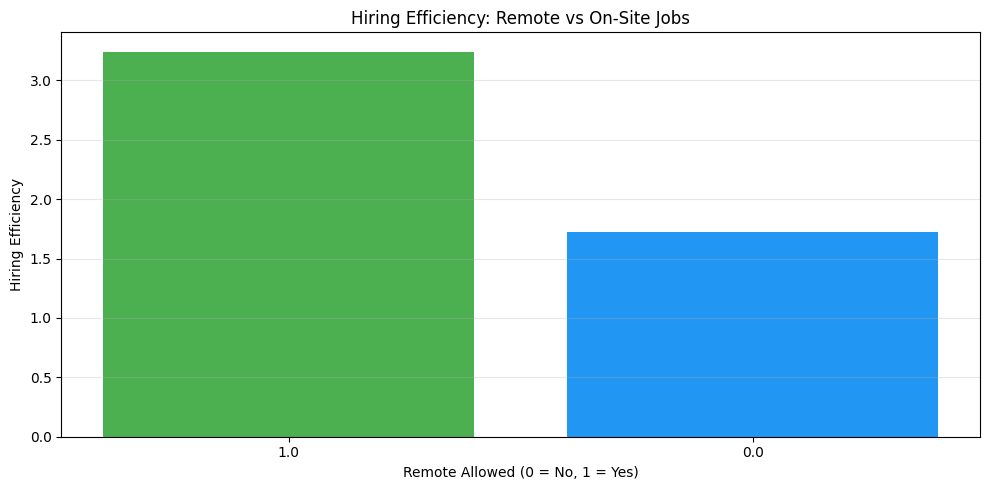

In [38]:
he_remote = (
    data.groupby('remote_allowed')
        .agg(
            total_postings=('job_id', 'count'),
            total_applicants=('applies', 'sum'),
            avg_salary=('normalized_salary', 'median')
        )
        .assign(
            hiring_efficiency=lambda x: x['total_applicants'] / x['total_postings']
        )
        .sort_values('hiring_efficiency', ascending=False)
        .reset_index()
)


plt.figure(figsize=(10,5))
plt.bar(
    he_remote['remote_allowed'].astype(str),
    he_remote['hiring_efficiency'],
    color=['#4CAF50', '#2196F3']
)

plt.title("Hiring Efficiency: Remote vs On-Site Jobs")
plt.xlabel("Remote Allowed (0 = No, 1 = Yes)")
plt.ylabel("Hiring Efficiency")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Hypothesis 11:** Sponsored postings yield higher hiring efficiency than organic postings.

In [39]:
he_sponsored = (
    data.groupby("sponsored")
        .agg(
            total_postings=('job_id', 'count'),
            total_applicants=('applies', 'sum'),
            avg_salary=('normalized_salary', 'median')
        )
        .assign(hiring_efficiency=lambda x: x["total_applicants"] / x["total_postings"])
        .sort_values("hiring_efficiency", ascending=False)
        .reset_index()
)

he_sponsored

,sponsored,total_postings,total_applicants,avg_salary,hiring_efficiency
0,0,123849,236207.25,81500.0,1.90722


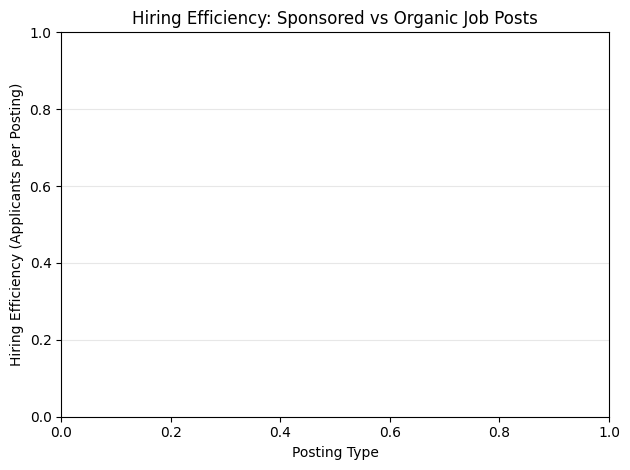

,sponsored,total_postings,total_applicants,avg_salary,hiring_efficiency
0,0,123849,236207.25,81500.0,1.90722


In [40]:
plt.title("Hiring Efficiency: Sponsored vs Organic Job Posts")
plt.ylabel("Hiring Efficiency (Applicants per Posting)")
plt.xlabel("Posting Type")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

he_sponsored

**Hypothesis 12:** Jobs posted through LinkedIn’s native domain (linkedin.com) have higher hiring efficiency than external domains.

In [41]:
#classifying into domain categories for clustering
def classify_domain(domain):
    domain = str(domain).lower()

    if "linkedin.com" in domain:
        return "LinkedIn Easy"


    ats_keywords = [
        "greenhouse", "workday", "lever", "myworkdayjobs",
        "smartrecruiters", "icims", "bamboohr", "ultipro"
    ]
    if any(k in domain for k in ats_keywords):
        return "ATS Platforms"

    job_board_keywords = [
        "indeed", "ziprecruiter", "monster", "glassdoor",
        "simplyhired", "careerbuilder", "snagajob", "click2apply"
    ]
    if any(k in domain for k in job_board_keywords):
        return "Job Boards"


    if domain.endswith(('.org', '.edu', '.gov', '.io', '.co')):
        return "Company Websites"

    return "Other"

In [42]:
data['domain_cluster'] = data['posting_domain'].apply(classify_domain)

In [43]:
he_domain = (
    data.groupby("domain_cluster")
        .agg(
            total_postings=('job_id', 'count'),
            total_applicants=('applies', 'sum')
        )
        .assign(hiring_efficiency=lambda x: x['total_applicants'] / x['total_postings'])
        .sort_values("hiring_efficiency", ascending=False)
        .reset_index()
)

he_domain

,domain_cluster,total_postings,total_applicants,hiring_efficiency
0,LinkedIn Easy,39969,110655.00,2.768521
1,ATS Platforms,18893,30479.50,1.613269
2,Other,50967,79988.25,1.569413
3,Company Websites,10068,13389.25,1.329882
4,Job Boards,3952,1695.25,0.428960


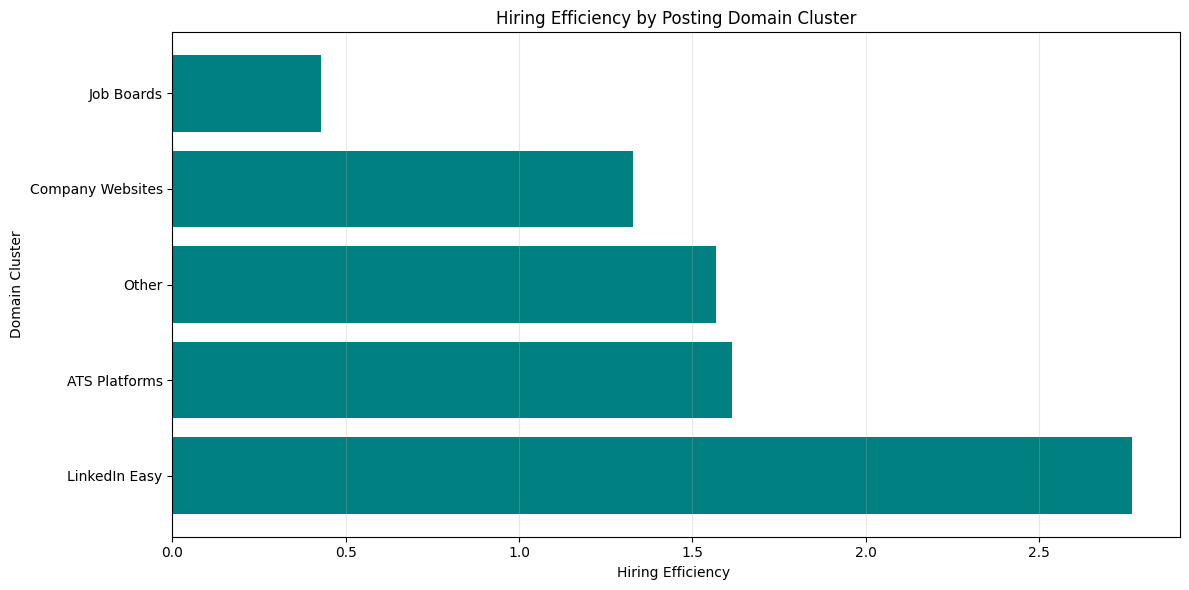

In [44]:
plt.figure(figsize=(12,6))
plt.barh(
    he_domain['domain_cluster'],
    he_domain['hiring_efficiency'],
    color='teal'
)

plt.xlabel("Hiring Efficiency ")
plt.ylabel("Domain Cluster")
plt.title("Hiring Efficiency by Posting Domain Cluster")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Hypothesis 13:** Jobs with higher views have higher hiring efficiency.

In [45]:
he_by_views = (
    data.groupby('views', observed=True)
        .agg(
            total_postings=('posting_count', 'sum'),
            total_applicants=('applies', 'sum')
        )
        .reset_index()
)

he_by_views['hiring_efficiency'] = (
    he_by_views['total_applicants'] / he_by_views['total_postings']
)

In [46]:
he_by_views

,views,total_postings,total_applicants,hiring_efficiency
0,1.0,4587,7624.00,1.662089
1,2.0,14417,20751.75,1.439394
2,3.0,16960,25524.75,1.504997
3,4.0,30012,42509.25,1.416408
4,5.0,14513,20998.75,1.446892
5,6.0,7834,11583.50,1.478619
6,7.0,4922,7183.50,1.459468
7,8.0,3376,4912.25,1.455050
8,9.0,2472,3718.00,1.504045
9,10.0,1926,3146.00,1.633437


/tmp/ipython-input-1503929618.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


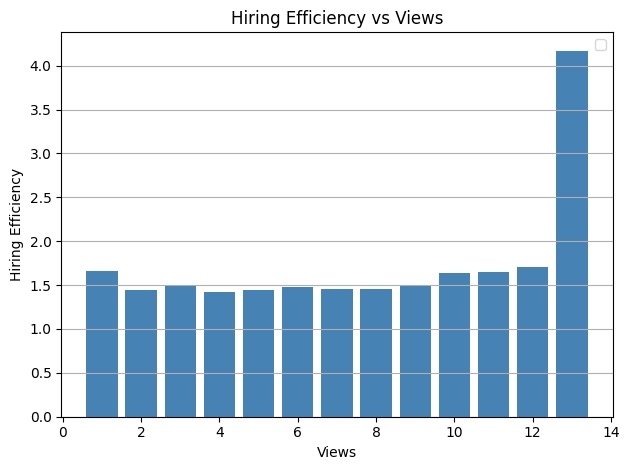

In [47]:
plt.figure()
plt.bar(
    he_by_views['views'],
    he_by_views['hiring_efficiency'],
    color='steelblue'
)

plt.title("Hiring Efficiency vs Views")
plt.xlabel("Views")
plt.ylabel("Hiring Efficiency")
plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.show()



**Hypothesis 14:** Jobs with longer posting duration (listed_time->expiry) have lower hiring efficiency.

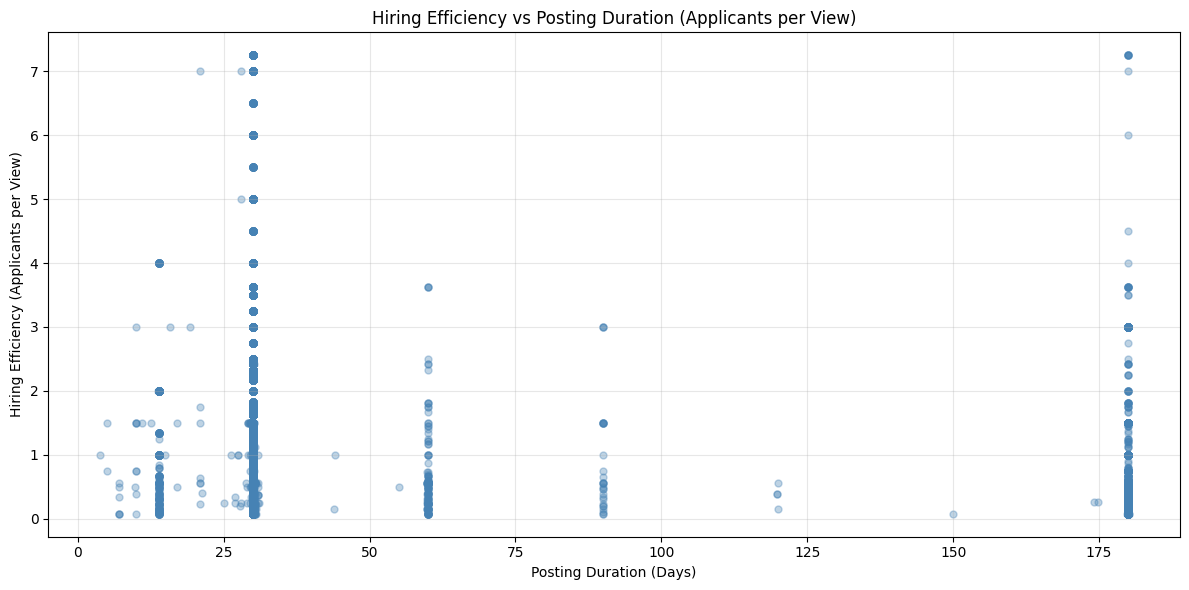

In [48]:
data['listed_time'] = pd.to_numeric(data['listed_time'], errors='coerce')
data['expiry'] = pd.to_numeric(data['expiry'], errors='coerce')
data['applies'] = pd.to_numeric(data['applies'], errors='coerce')


data['posting_duration_days'] = (data['expiry'] - data['listed_time']) / (1000 * 60 * 60 * 24)
data['hiring_efficiency'] = data['applies'] / data['views']

plt.figure(figsize=(12, 6))
plt.scatter(
    data['posting_duration_days'],
    data['hiring_efficiency'],
    alpha=0.35,
    color='steelblue',
    s=25
)

plt.title("Hiring Efficiency vs Posting Duration (Applicants per View)")
plt.xlabel("Posting Duration (Days)")
plt.ylabel("Hiring Efficiency (Applicants per View)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
